# Kaggle submission

Load pre-scaled Kaggle data + a trained model, tune the threshold on a chosen metric, write the submission parquet.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentinel.ml_logic.metrics import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.viz import plot_timeline
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

from sentinel.params import WINDOW_SIZE
from sentinel.ml_logic.data import MODELS_DIR, PROCESSED_DIR, SUBMISSIONS_DIR
from sentinel.ml_logic.scorer import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics import esa_metric, event_f05, event_f1, f05_score

import sys
sys.path.insert(0, str(MODELS_DIR.parent / "kaggle"))
from submission import make_submission, submission_summary, default_submission_path

KAGGLE_DIR = PROCESSED_DIR / "kaggle"
print("window :", WINDOW_SIZE)
print("kaggle :", KAGGLE_DIR)
print("models :", MODELS_DIR)

window : 100
kaggle : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
models : /Users/helena.schulz.ext/code/alexfederolf/sentinel/models


## 2. Load data

- `data/processed/kaggle/test_scaled` + `test_ids` — unlabeled Kaggle test, what we submit on
- `data/processed/test_intern_scaled` + `y_test_intern` — held-out labeled split for threshold tuning (smaller + not seen during training)

In [2]:
X_val    = np.load(PROCESSED_DIR / "test_intern_scaled.npy")
y_val    = np.load(PROCESSED_DIR / "y_test_intern.npy")
X_test   = np.load(KAGGLE_DIR   / "test_scaled.npy")
test_ids = np.load(KAGGLE_DIR   / "test_ids.npy")

with open(KAGGLE_DIR / "preprocessing_config.json") as f:
    features = json.load(f)["target_channels"]

print(f"X_val   : {X_val.shape}   anomalies: {int(y_val.sum()):,} ({y_val.mean()*100:.2f}%)")
print(f"X_test  : {X_test.shape}   test_ids: {test_ids.shape}")
print(f"features: {len(features)}")

X_val   : (2186220, 58)   anomalies: 214,961 (9.83%)
X_test  : (521280, 58)   test_ids: (521280,)
features: 58


## 3. Load model from `models/`

Swap the `MODEL` line to pick PCA / LSTM-AE / CNN-AE.

In [3]:
MODEL = "pca"    # "pca" | "lstm_ae" | "cnn_ae"

if MODEL == "pca":
    with open(MODELS_DIR / "pca.pkl", "rb") as f:
        model = pickle.load(f)
    TOPK = None
else:
    from tensorflow.keras.models import load_model
    model = load_model(MODELS_DIR / f"{MODEL}.keras", compile=False)
    TOPK = 5   # LSTM/CNN: anomalies hit a few channels, take top-k per-channel MSE

print(f"loaded: {MODEL}   topk={TOPK}")

loaded: pca   topk=None


## 4. Score val + tune threshold

Pick the metric to optimise. ESA = Kaggle-leaderboard ranking (`corrected_event_f05`).

In [4]:
METRIC = esa_metric          # esa_metric | event_f05 | event_f1 | f05_score
SCORE_KEY = "f_score"        # None for bare scalars like f05_score

t0 = time.time()
val_scores = score_windows(model, X_val, win=WINDOW_SIZE, topk=TOPK)
print(f"score_windows(val): {time.time() - t0:.2f}s   range: {val_scores.min():.4f} – {val_scores.max():.4f}")

t0 = time.time()
tuned = tune_threshold(
    scores    = val_scores,
    y_true    = y_val,
    metric_fn = METRIC,
    n_sweep   = 30,          # each step runs the event-metric once — keep moderate
    score_key = SCORE_KEY,
)
threshold = tuned["threshold"]
print(f"tune_threshold: {time.time() - t0:.1f}s")
print(f"best threshold: {threshold:.6f}   {METRIC.__name__}={tuned['score']:.4f}")

score_windows(val): 0.63s   range: 0.0258 – 3.0895


tune_threshold: 0.2s
best threshold: 0.246956   corrected_event_f05=0.7981


## 5. Validation results

threshold            : 0.246956
event_f05 (bootcamp) : 0.8228   recall=0.4815  precision=1.0000
corrected_event_f05  : 0.7981   TNR=0.9550   ← Kaggle-equivalent metric
row precision        : 0.6015
row recall           : 0.6224
row f1               : 0.6118
val flag rate        : 10.1728%


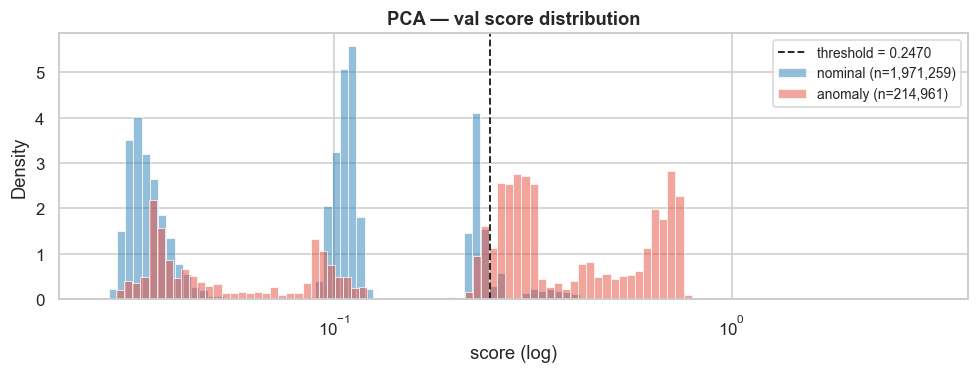

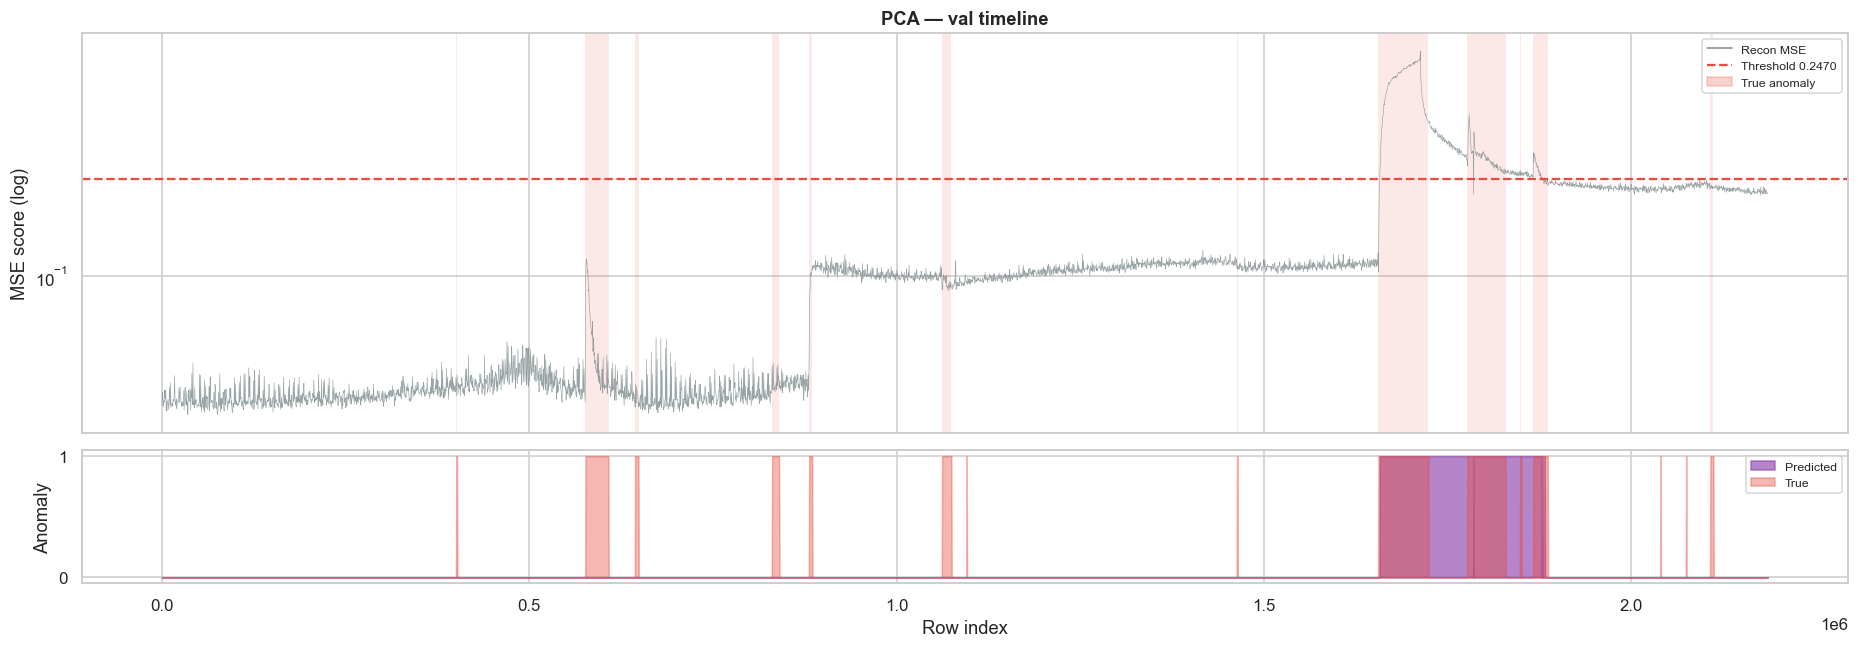

In [5]:
# Apply tuned threshold on validation and report event / row metrics + charts.
y_pred_val = (val_scores > threshold).astype(np.int8)

ev  = event_f05(y_val, y_pred_val)
esa = corrected_event_f05(y_val, y_pred_val)
rw  = row_precision_recall(y_val, y_pred_val)
flag_rate = y_pred_val.mean()

print(f"threshold            : {threshold:.6f}")
print(f"event_f05 (bootcamp) : {ev['f_score']:.4f}   recall={ev['recall']:.4f}  precision={ev['precision']:.4f}")
print(f"corrected_event_f05  : {esa['f_score']:.4f}   TNR={esa['tnr']:.4f}   ← Kaggle-equivalent metric")
print(f"row precision        : {rw['precision']:.4f}")
print(f"row recall           : {rw['recall']:.4f}")
print(f"row f1               : {rw['f1']:.4f}")
print(f"val flag rate        : {flag_rate:.4%}")

# ── Score distribution: nominal vs anomaly ────────────────────────────────────
nom  = val_scores[y_val == 0]
anom = val_scores[y_val == 1]
NSAMP = 100_000
rng = np.random.default_rng(42)
nom_s  = nom[rng.choice(len(nom),  size=min(NSAMP, len(nom)),  replace=False)]
anom_s = anom[rng.choice(len(anom), size=min(NSAMP, len(anom)), replace=False)] if len(anom) else anom

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(nom_s,  bins=100, ax=ax, color=NOMINAL_COLOR, alpha=0.5,
             stat='density', label=f'nominal (n={len(nom):,})', log_scale=(True, False))
if len(anom_s):
    sns.histplot(anom_s, bins=100, ax=ax, color=ANOMALY_COLOR, alpha=0.5,
                 stat='density', label=f'anomaly (n={len(anom):,})', log_scale=(True, False))
ax.axvline(threshold, ls='--', color='k', lw=1.2, label=f'threshold = {threshold:.4f}')
ax.set_xlabel('score (log)')
ax.set_title(f'{MODEL.upper()} — val score distribution', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ── Timeline ─────────────────────────────────────────────────────────────────
_ = plot_timeline(val_scores, y_val, threshold,
                  title=f'{MODEL.upper()} — val timeline',
                  log_y=True)


## 6. Score test + write submission

In [6]:
t0 = time.time()
test_scores = score_windows(model, X_test, win=WINDOW_SIZE, topk=TOPK)
labels = (test_scores > threshold).astype(np.uint8)
print(f"score_windows(test): {time.time() - t0:.2f}s")

out_path = default_submission_path(f"submission_{MODEL}_{METRIC.__name__}")
sub = make_submission(
    predictions     = labels,
    test_ids        = test_ids,
    out_path        = out_path,
    validate_schema = True,
)

print("written     :", out_path)
print("summary     :", submission_summary(sub))
sub.head()

score_windows(test): 0.15s
written     : /Users/helena.schulz.ext/code/alexfederolf/sentinel/kaggle/submissions/submission_pca_corrected_event_f05.parquet
summary     : {'rows': 521280, 'positive_rows': 2800, 'positive_rate': 0.005371, 'n_segments': 10}


,id,is_anomaly
0,14728321,0
1,14728322,0
2,14728323,0
3,14728324,0
4,14728325,0
